In [1]:
import numpy as np
from torchvision.datasets import CocoDetection
import datetime
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd
import sys 
sys.path.append("/home/tyfei/cyroem")
import utils
import torch
import importlib 
import json
import modules
import data
importlib.reload(utils)
importlib.reload(modules)
importlib.reload(data)
import torchmetrics

import pycocotools.coco
import pycocotools.mask
import torchvision.transforms.v2 as transforms
from transformers import DetrConfig, DetrForObjectDetection, DetrImageProcessor, DetrForSegmentation, ConditionalDetrForObjectDetection,ConditionalDetrConfig,ConditionalDetrForSegmentation

/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [36]:
dataset = data.CocoDetection(
"/data/transformer_project/transforemer_model/train_data/training/data/", 
"/data/transformer_project/transforemer_model/train_data/training/data/annotations/sllt0039_9_5_10.pkl",
                            is_npy=True, filter_class=[3, 4, 7, 12, 14], map_class={"3":0, "4":1, "7":2, "12":3, "14":4}, require_mask=True, transform=data.getConstantTransform(), add_classname=True, norm="hist",filtermin=3
)

loading annotations into memory...
Done (t=0.10s)
creating index...
index created!


In [37]:
for t in dataset:
    break 
t

{'pixel_values': tensor([[[0.2470, 0.2167, 0.0824,  ..., 0.6188, 0.3969, 0.5098],
          [0.2565, 0.2050, 0.1208,  ..., 0.6079, 0.5075, 0.4503],
          [0.3153, 0.3471, 0.3543,  ..., 0.6383, 0.6557, 0.6767],
          ...,
          [0.5735, 0.4925, 0.5957,  ..., 0.7568, 0.5348, 0.4310],
          [0.4154, 0.4425, 0.6298,  ..., 0.6165, 0.4590, 0.3910],
          [0.2092, 0.4316, 0.5618,  ..., 0.5116, 0.4213, 0.5499]],
 
         [[0.7320, 0.4706, 0.4167,  ..., 0.5402, 0.2991, 0.5475],
          [0.3446, 0.3651, 0.3443,  ..., 0.4970, 0.3313, 0.2685],
          [0.3627, 0.4157, 0.4097,  ..., 0.5047, 0.5387, 0.5309],
          ...,
          [0.6330, 0.5070, 0.4195,  ..., 0.8643, 0.8666, 0.8731],
          [0.4470, 0.4084, 0.4401,  ..., 0.7625, 0.7586, 0.6423],
          [0.7067, 0.3492, 0.3929,  ..., 0.6462, 0.6837, 0.3074]],
 
         [[0.7680, 0.6934, 0.6004,  ..., 0.4190, 0.2309, 0.3951],
          [0.5122, 0.5071, 0.4327,  ..., 0.5052, 0.3087, 0.2295],
          [0.4532, 0.386

In [58]:
df = {"obj":[], "size":[], "pos_x":[], "pos_y":[], "pos_z":[], "label":[]} 
for t in dataset:
    l = t["labels"]
    pos_z = l["pos"]
    for obj, size, mask, label in zip(l["names"], l["area"], l["masks"], l["item_id"]):
        if obj == "ribo":
            continue
        mask = mask.numpy()
        x, y = np.where(mask)
        pos_x = x.mean()
        pos_y = y.mean()
        df["obj"].append(obj)
        df["size"].append(size.item())
        df["label"].append(label)
        df["pos_x"].append(pos_x)
        df["pos_y"].append(pos_y)
        df["pos_z"].append(pos_z)

In [44]:
l.keys()

dict_keys(['bboxes', 'class_labels', 'item_id', 'masks', 'names', 'orig_size', 'size', 'image_id', 'boxes', 'area', 'iscrowd', 'pos'])

In [68]:
mix_labels = {
    "TS_023": "/data/transformer_project/transforemer_model/train_data/20230328_TS_023/amira/TS_023.mrc_10.30Apx.labels/", 
    "TS_005": "/data/transformer_project/transforemer_model/train_data/20230328_TS_005/amira/TS_005.mrc_10.30Apx.labels/", 
    "TS_031": "/data/transformer_project/transforemer_model/train_data/TS_031/amira/TS_031.mrc_10.30Apx.labels/", 
    "sllt0039": "/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0039/amira/sllt0039_9.62Apx.labels/", 
    "sllt0051": "/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0051/amira/sllt0051_9.62Apx.labels/", 
    "sllt0081": "/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0081/amira/sllt0081_9.62Apx.labels/", 
}

In [ ]:
required = {"ribosome": 0, "mitochondria": 1, "nucleus": 2, "endoplasmic_reticulum_or_Golgi": 3}
df = {"obj":[], "size":[], "pos_x":[], "pos_y":[], "pos_z":[], "label":[]}
r = mix_labels["sllt0081"]
for i in os.listdir("/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0081/amira/sllt0081_9.62Apx.labels/"):
    if "labels" not in i:
        print(i)
        continue
    pos = int(i[i.rfind("labels")+6:])
    for j in os.listdir("/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0081/amira/sllt0081_9.62Apx.labels/" + i):
        if j.endswith(".mrc"):
            # print(i, j)
            name = j.split(".")[0] 
            if name not in required:
                continue
            t = utils.readTomogram("/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0081/amira/sllt0081_9.62Apx.labels/" + i + "/" + j)
            labels, cnts = np.unique(t, return_counts=True)
            for k in labels:
                if k == 0:
                    continue
                x, y = np.where(t == k)
                df["obj"].append(name)
                df["size"].append(cnts[labels == k][0])
                df["pos_x"].append(np.mean(x))
                df["pos_y"].append(np.mean(y))
                df["pos_z"].append(pos)
                df["label"].append(k)
df = pd.DataFrame(df)
df

,obj,size,pos_x,pos_y,pos_z,label
0,mitochondria,63369,482.665152,568.019994,400,1
1,mitochondria,27350,617.612358,406.120219,400,2
2,endoplasmic_reticulum_or_Golgi,11483,141.947313,469.310807,400,1
3,endoplasmic_reticulum_or_Golgi,2790,125.074552,592.479570,400,2
4,endoplasmic_reticulum_or_Golgi,3373,239.336792,527.608657,400,3
...,...,...,...,...,...,...
739,endoplasmic_reticulum_or_Golgi,18916,200.801914,110.168006,100,3
740,endoplasmic_reticulum_or_Golgi,17596,206.464026,361.082689,100,4
741,endoplasmic_reticulum_or_Golgi,3164,261.969975,395.886536,100,5
742,endoplasmic_reticulum_or_Golgi,3231,339.710616,425.665119,100,6


('endoplasmic_reticulum_or_Golgi', 1)
[400 395 390 385 380 375 370 365 360 355 350 345 340 335 330 325 320 315
 310 305 300 295 290 285 280 275 270 265 260 255 250 245 240 235 230 225
 220 215 210 205 200 195 190 185 180 175 170 165 160 155 150 145 140 135
 130 125 120 115 110 105 100]


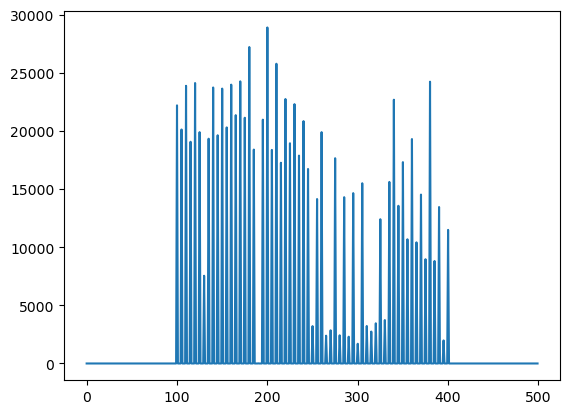

('endoplasmic_reticulum_or_Golgi', 2)
[400 395 390 385 380 375 370 365 360 355 350 345 340 335 330 325 320 315
 310 305 300 295 290 285 280 275 270 265 260 255 250 245 240 235 230 225
 220 215 210 205 200 195 190 185 180 175 170 165 160 155 150 145 140 135
 130 125 120 115 110 105 100]


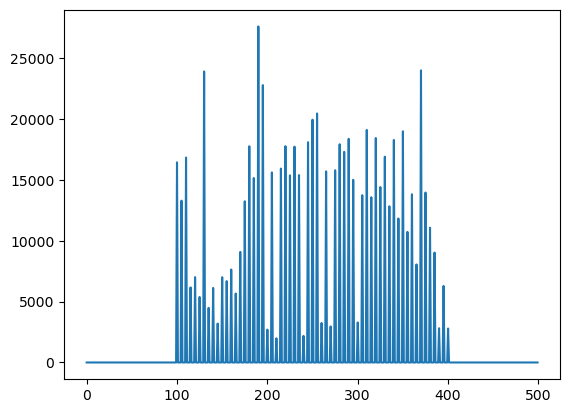

('endoplasmic_reticulum_or_Golgi', 3)
[400 395 390 385 380 375 370 365 360 355 350 345 340 335 330 325 320 315
 310 305 300 295 290 285 280 275 270 265 260 255 250 245 240 235 230 225
 220 215 210 205 200 195 190 185 180 175 170 165 160 155 150 145 140 135
 130 125 120 115 110 105 100]


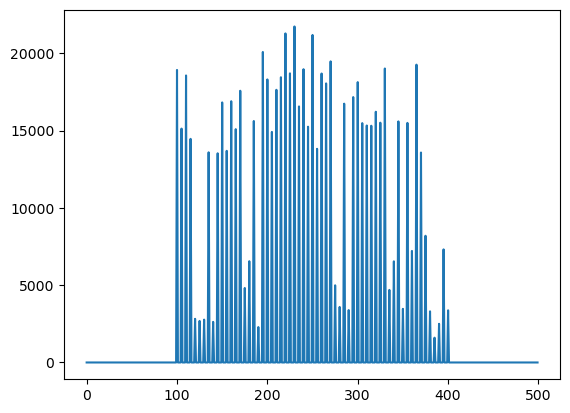

('endoplasmic_reticulum_or_Golgi', 4)
[390 385 380 375 370 365 360 355 350 345 340 335 330 325 320 315 310 305
 300 295 290 285 280 275 270 265 260 255 250 245 240 235 230 225 220 215
 210 205 200 195 190 185 180 175 170 165 160 155 150 145 140 135 130 125
 120 115 110 105 100]


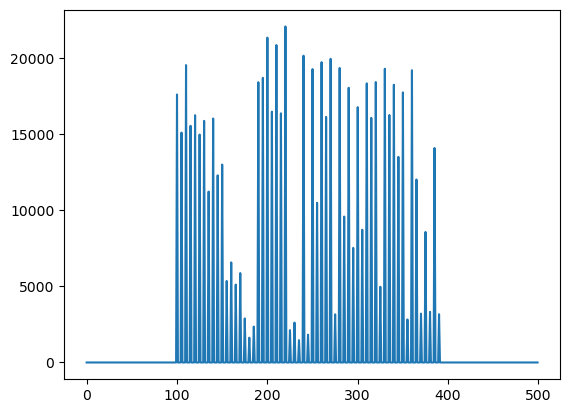

('endoplasmic_reticulum_or_Golgi', 5)
[390 385 380 375 370 365 360 355 350 345 340 335 330 325 320 315 310 305
 300 295 290 285 280 275 270 265 260 255 250 245 240 235 230 225 220 215
 210 205 200 195 190 185 180 175 170 165 160 155 150 145 140 135 130 125
 120 115 110 105 100]


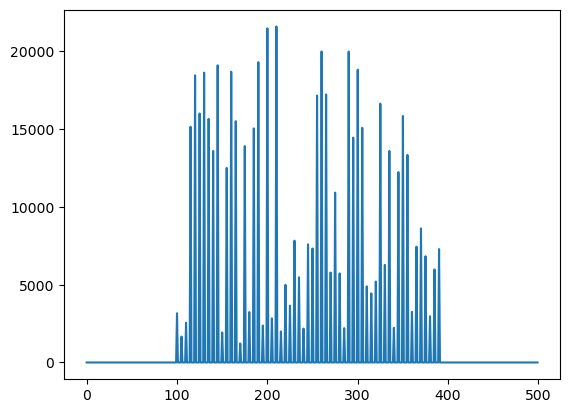

('endoplasmic_reticulum_or_Golgi', 6)
[380 360 355 350 340 335 330 325 320 315 310 305 300 295 290 285 280 275
 270 265 260 255 250 245 240 235 230 225 220 215 210 205 200 195 190 185
 180 175 170 165 160 155 150 145 140 135 130 125 120 115 110 105 100]


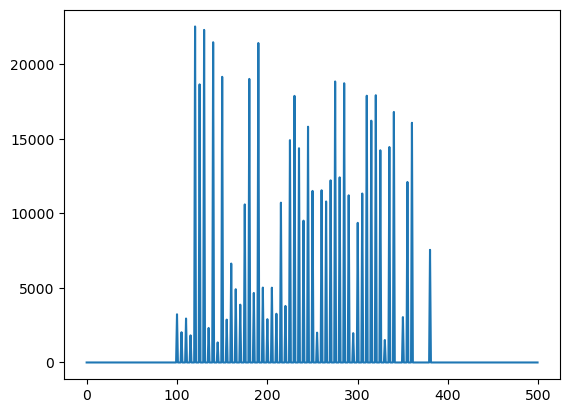

('endoplasmic_reticulum_or_Golgi', 7)
[360 350 340 335 330 320 315 310 305 300 295 290 285 280 275 270 265 260
 255 250 245 240 235 230 225 220 215 210 205 200 195 190 185 180 175 170
 165 160 155 150 145 140 135 130 125 120 115 110 105 100]


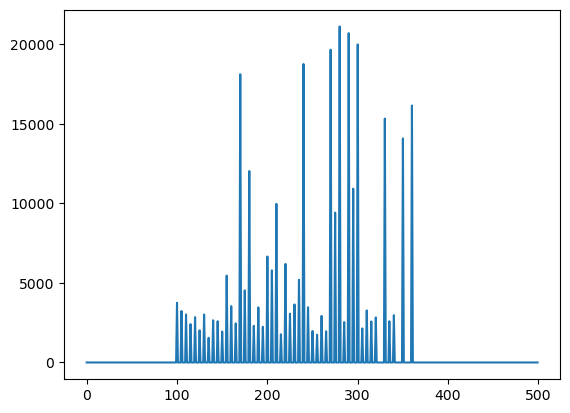

('endoplasmic_reticulum_or_Golgi', 8)
[340 330 320 315 310 300 295 290 285 280 275 270 265 260 255 250 245 240
 235 230 225 220 215 210 200 190 185 180 175 170 165 160 155 150 145 140
 135 130 125 120 115 110 105]


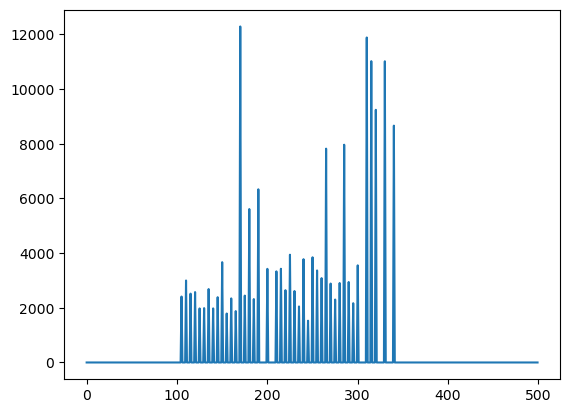

('endoplasmic_reticulum_or_Golgi', 9)
[340 330 320 315 310 300 290 285 280 275 270 265 260 255 250 245 240 235
 230 225 220 215 210 200 190 180 175 170 165 160 155 150 145 140 135 130
 125 120 115 110]


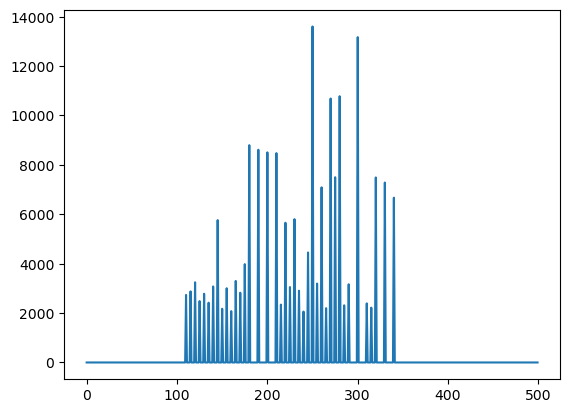

('endoplasmic_reticulum_or_Golgi', 10)
[340 330 320 300 290 280 275 270 260 255 250 245 240 230 225 220 210 200
 190 180 170 165 160 155 150 140 135 130 125 120 115 110]


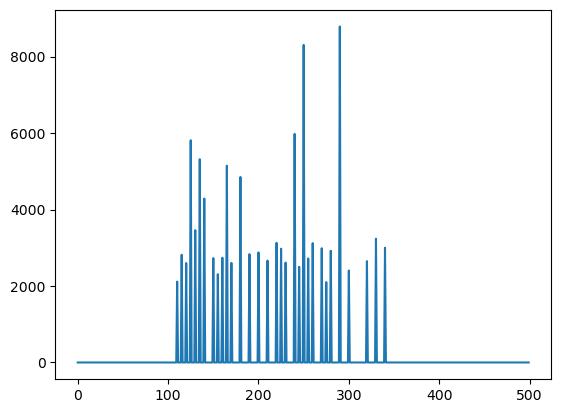

('endoplasmic_reticulum_or_Golgi', 11)
[330 320 290 280 270 260 255 250 240 230 170 165 160 155 150 140 130 125
 120 115]


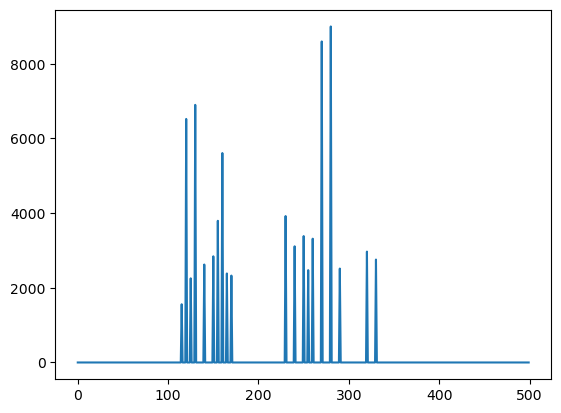

('endoplasmic_reticulum_or_Golgi', 12)
[280 270 260 250 240 230 170 160 155 150 140 130 120]


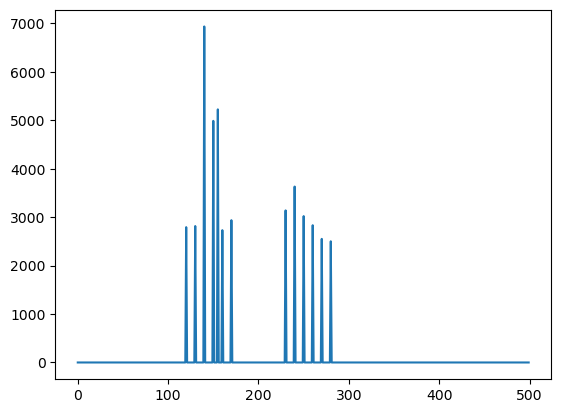

('endoplasmic_reticulum_or_Golgi', 13)
[280 250 240 170 160 150 140]


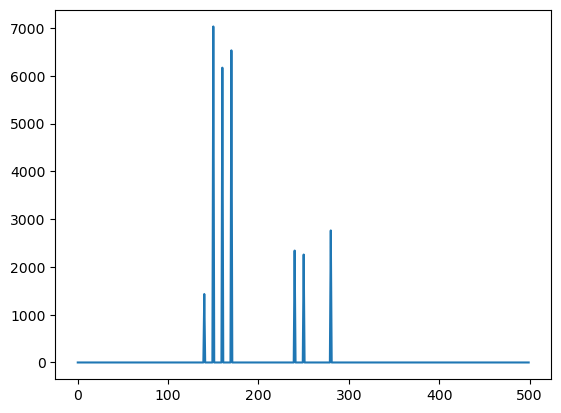

('endoplasmic_reticulum_or_Golgi', 14)
[250 170]


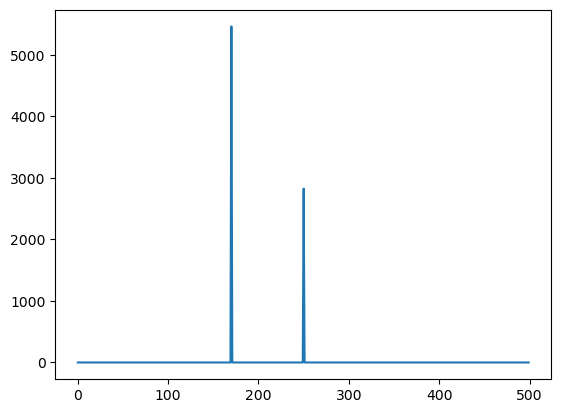

('mitochondria', 1)
[400 395 390 385 380 375 370 365 360 355 350 345 340 335 330 325 320 315
 310 305 300 295 290 285 280 275 270 265 260 255 250 245 240 235 230 225
 220 215 210 205 200 195 190 185 180 175 170 165 160 155 150 145 140 135
 130 125 120 115 110 105 100]


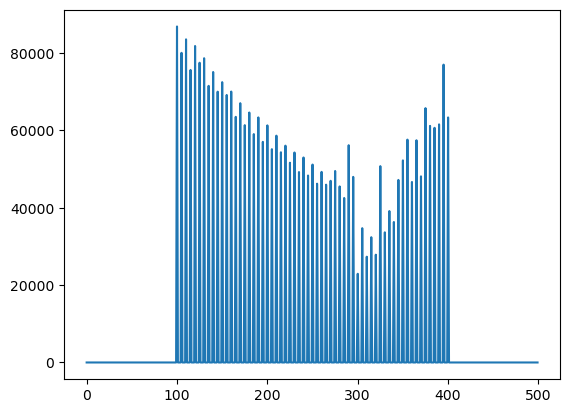

('mitochondria', 2)
[400 390 385 380 375 370 365 360 355 350 345 340 335 330 325 320 315 310
 305 300 295 290 285 280 275 270 265 260 255 250 245 240 235 230 225 220
 215 210 205 200 195 190 185 180 175 170 165 160 155 150 145 140 135 130
 125 120 115 110 105 100]


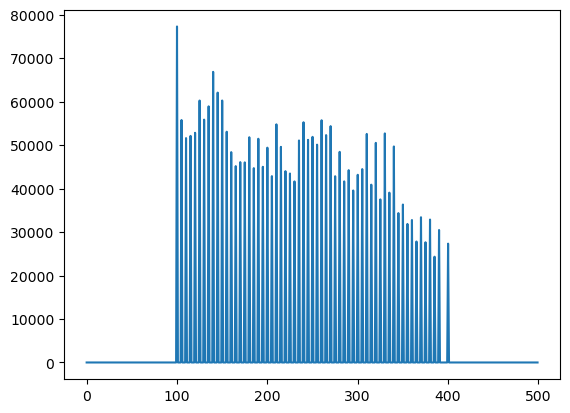

('mitochondria', 3)
[340 335 330 325 320 315 310 305 300 295 290 285 280 275 270 265 260 255
 250 245 240 235 230 225 220 215 210 205 200 195 190 185 180 175 170 165
 160 155 150 145 140 135 130 125 120 115 110 105 100]


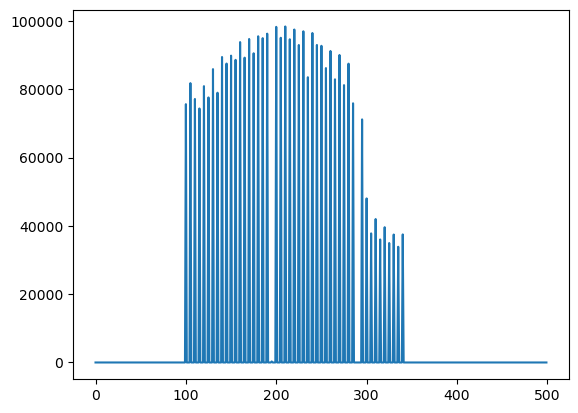

('mitochondria', 4)
[340 335 330 325 320 315 310 305 300 290 195]


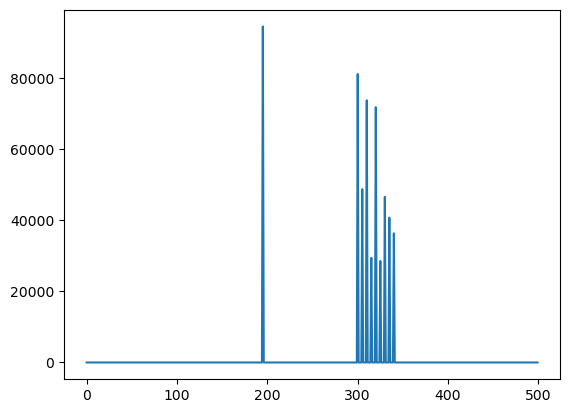

('mitochondria', 5)
[290]


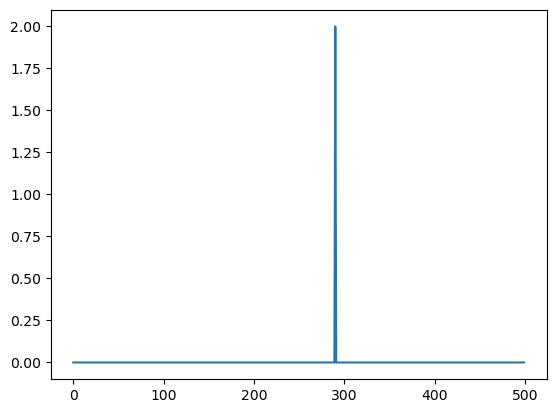

('mitochondria', 6)
[290]


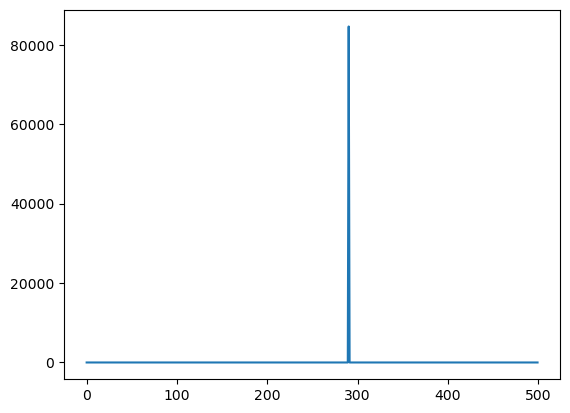

In [67]:
df = pd.DataFrame(df)
for i, r in df.groupby(["obj", "label"]):
    print(i)
    a = np.zeros([500])
    print(r["pos_z"].values)
    a[r["pos_z"].astype(int).values] = r["size"]
    plt.plot(a)
    plt.show()
    plt.close()

In [53]:
df.head()

,obj,size,pos_x,pos_y,pos_z,label
0,ribo,228,124.478070,213.736842,100.0,sllt0039_9_5_3_1
1,ribo,214,520.780374,91.308411,100.0,sllt0039_9_5_3_2
2,nucleus,136609,481.190112,101.037062,100.0,sllt0039_9_5_7_1
3,endoplasmic_reticulum_or_Golgi,1522,126.096583,183.352825,100.0,sllt0039_9_5_12_1
4,nucleus,136509,485.981503,98.970178,110.0,sllt0039_9_5_7_1


('endoplasmic_reticulum_or_Golgi', 1)


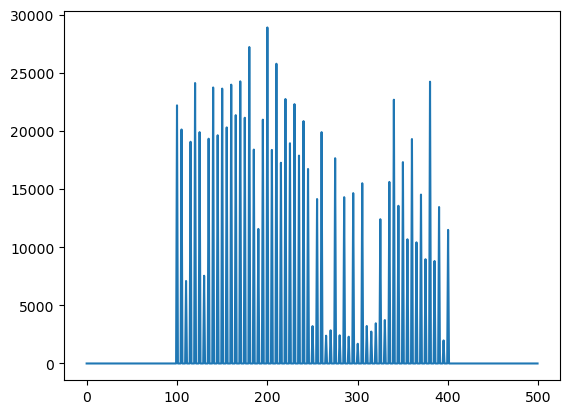

('endoplasmic_reticulum_or_Golgi', 2)


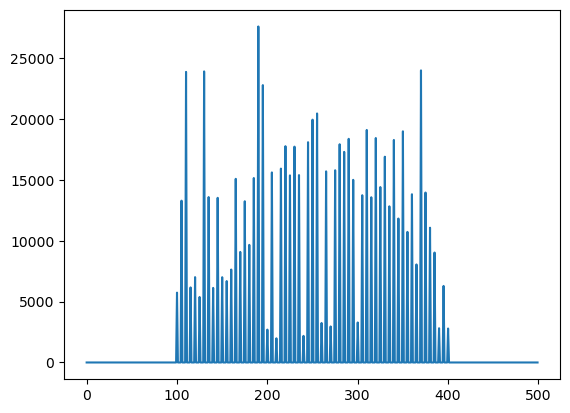

('endoplasmic_reticulum_or_Golgi', 3)


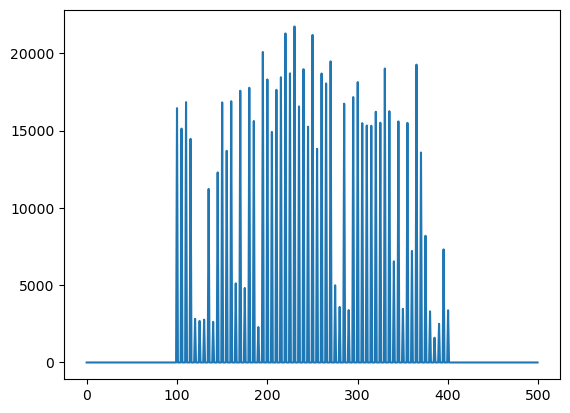

('endoplasmic_reticulum_or_Golgi', 4)


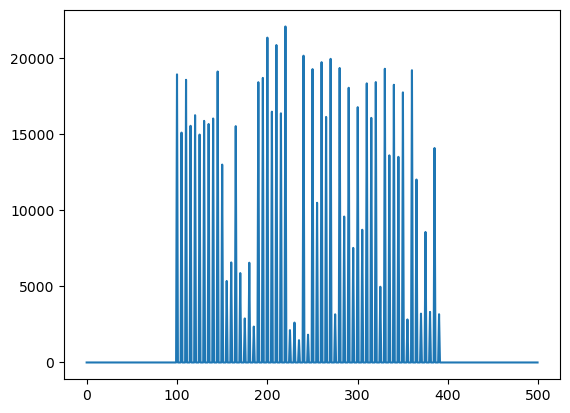

('endoplasmic_reticulum_or_Golgi', 5)


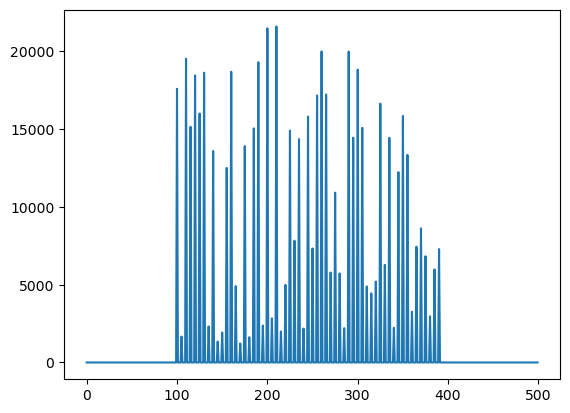

('endoplasmic_reticulum_or_Golgi', 6)


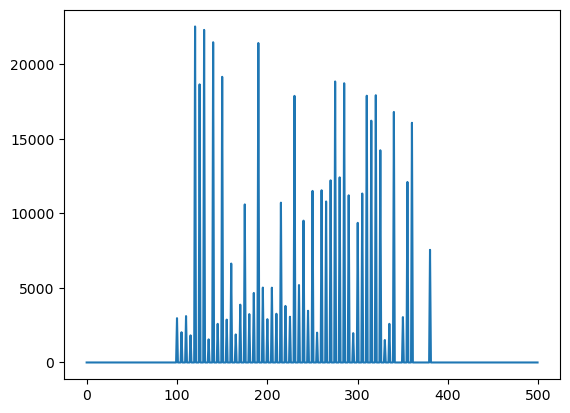

('endoplasmic_reticulum_or_Golgi', 7)


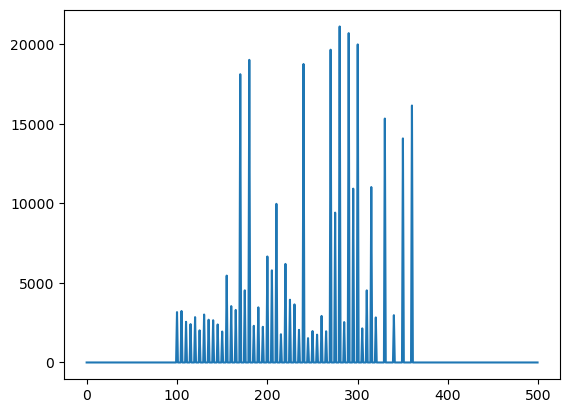

('endoplasmic_reticulum_or_Golgi', 8)


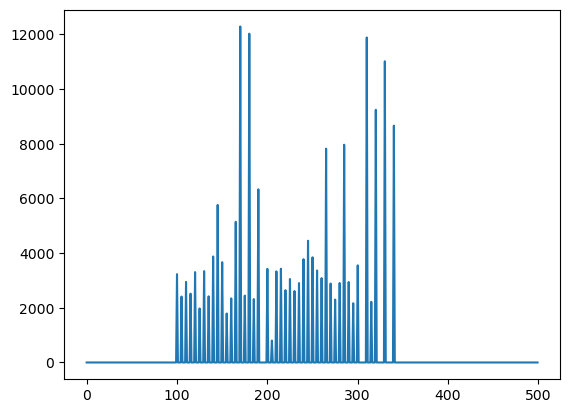

('endoplasmic_reticulum_or_Golgi', 9)


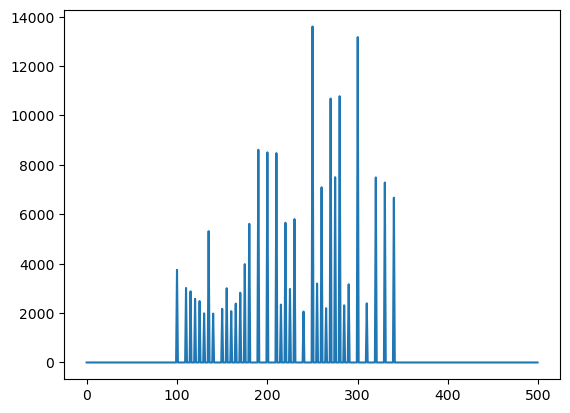

('endoplasmic_reticulum_or_Golgi', 10)


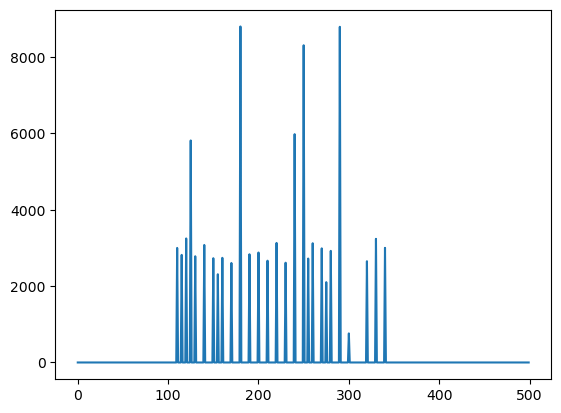

('endoplasmic_reticulum_or_Golgi', 11)


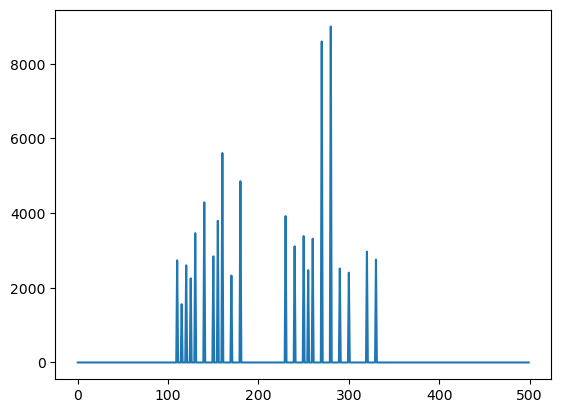

('endoplasmic_reticulum_or_Golgi', 12)


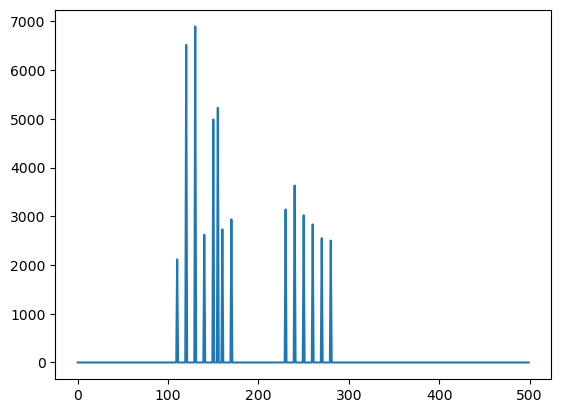

('endoplasmic_reticulum_or_Golgi', 13)


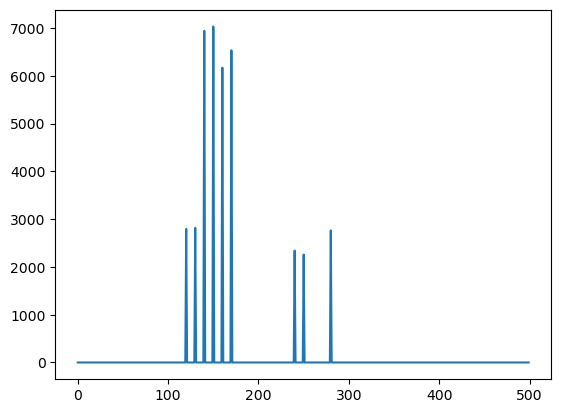

('endoplasmic_reticulum_or_Golgi', 14)


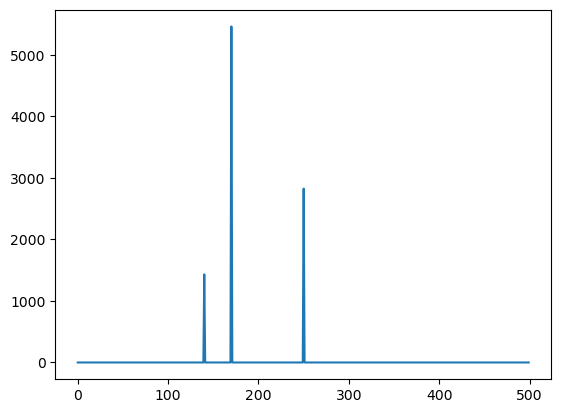

('mitochondria', 1)


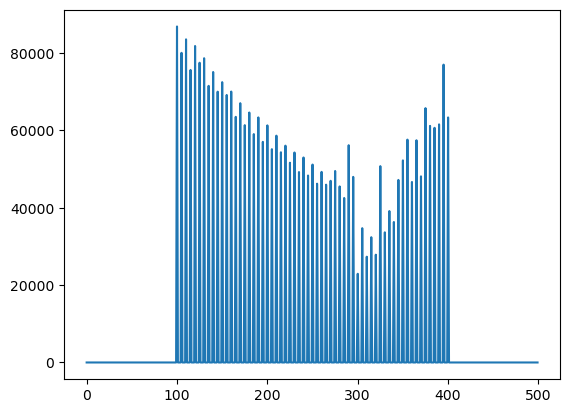

('mitochondria', 2)


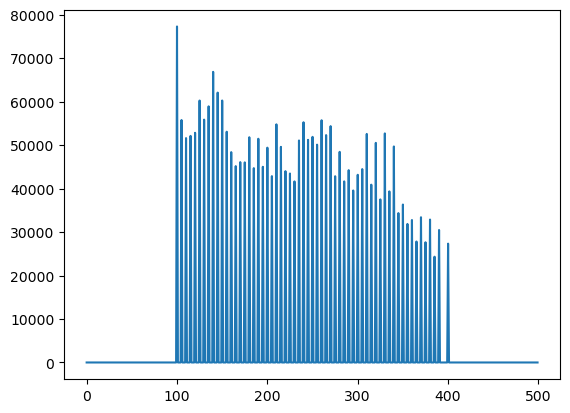

('mitochondria', 3)


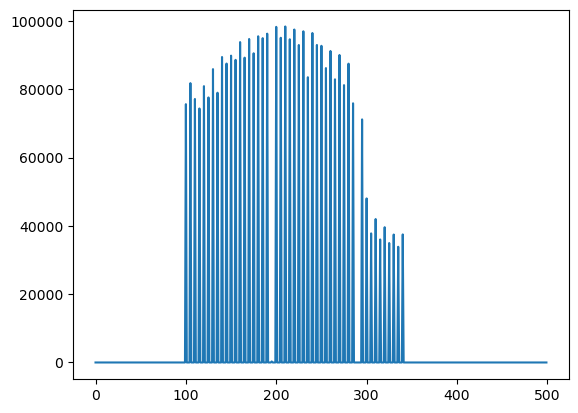

('mitochondria', 4)


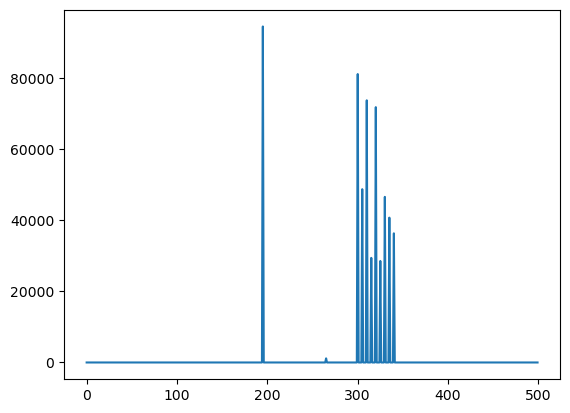

('mitochondria', 5)


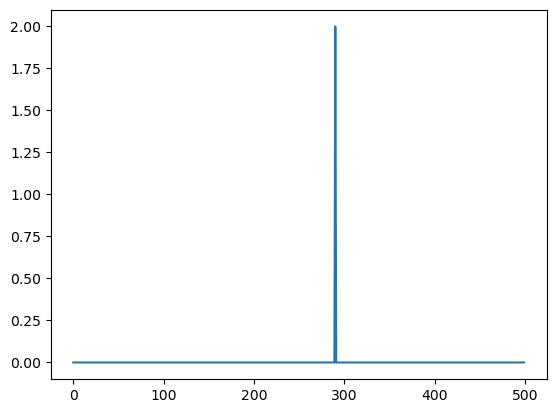

('mitochondria', 6)


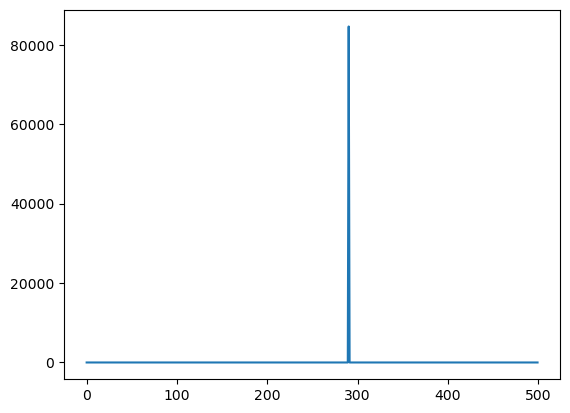

In [29]:
for i, r in df.groupby(["obj", "label"]):
    print(i)
    a = np.zeros([500])
    a[r["pos_z"]] = r["size"]
    plt.plot(a)
    plt.show()
    plt.close()

In [2]:
dataset = data.MrcDataset(
    "/data/transformer_project/transforemer_model/train_data/training/newdata/sllt0039.pkl",
    norm="hist",
    map_class={"ribosome": 0, "mitochondria": 1, "nucleus": 2},
    reshape=800,
    gap=5,
    length_for_average=10,
    transform=data.getDefaultTransform(),
    add_classname=True,
)

dataset2 = data.TestDatasetMrc(
    "/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0039/tomo/sllt0039_9.62Apx.mrc",
    norm="hist",
    reshape=800,
    gap=5,
    length_for_average=10,
)

dataset map classes:  {'ribosome': 0, 'mitochondria': 1, 'nucleus': 2}


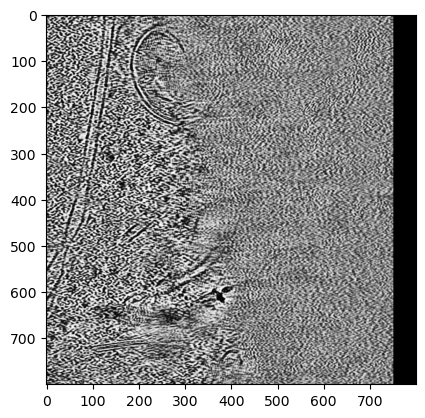

In [ ]:
pv = dataset[5]
plt.imshow(pv["pixel_values"][0], cmap="gray")


In [34]:
dataset2.__getitem__(pos=101)

/home/feity/cryoem/data.py:1169: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  "pixel_mask": torch.tensor(mask),


{'pixel_values': tensor([[[0.3145, 0.3212, 0.1617,  ..., 0.5627, 0.2000, 0.6670],
          [0.3014, 0.2777, 0.1207,  ..., 0.4187, 0.3775, 0.2639],
          [0.1965, 0.2222, 0.2149,  ..., 0.5710, 0.5223, 0.5749],
          ...,
          [0.4681, 0.4014, 0.4350,  ..., 0.6922, 0.5087, 0.4580],
          [0.3355, 0.3226, 0.4563,  ..., 0.5297, 0.4622, 0.4327],
          [0.1231, 0.3717, 0.3602,  ..., 0.6000, 0.3968, 0.5518]],
 
         [[0.9671, 0.5234, 0.4550,  ..., 0.3206, 0.0670, 0.9774],
          [0.4227, 0.4915, 0.4122,  ..., 0.3038, 0.1710, 0.1564],
          [0.2597, 0.4202, 0.3628,  ..., 0.4317, 0.3209, 0.3538],
          ...,
          [0.4848, 0.5999, 0.4946,  ..., 0.8102, 0.8518, 0.8138],
          [0.3070, 0.3086, 0.4816,  ..., 0.6031, 0.6988, 0.5965],
          [0.8217, 0.4266, 0.4090,  ..., 0.8244, 0.6214, 0.8652]],
 
         [[0.6177, 0.7916, 0.7245,  ..., 0.3610, 0.1329, 0.3635],
          [0.6347, 0.6611, 0.5721,  ..., 0.3365, 0.2228, 0.1839],
          [0.5077, 0.531

In [3]:
dataset._get_slice(10).shape

(3, 1024, 1024)

In [2]:
importlib.reload(utils)
model = utils.loadModel("/data/transformer_project/transforemer_model/train_data/training/results/conditional_detr_mrc_final/fold1_retrain_mm","epoch=33-total_validate_loss=1.2724.ckpt")
model = model.eval() 

Some weights of ConditionalDetrForObjectDetection were not initialized from the model checkpoint at microsoft/conditional-detr-resnet-50 and are newly initialized because the shapes did not match:
- class_labels_classifier.bias: found shape torch.Size([91]) in the checkpoint and torch.Size([4]) in the model instantiated
- class_labels_classifier.weight: found shape torch.Size([91, 256]) in the checkpoint and torch.Size([4, 256]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torch/nn/modules/transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


model at stage  stage 1 mask
model with output classes 5
model receiving class weights tensor([  1.0000,   5.0000, 100.0000,   3.0000,   0.1000])
using consistency regularization coef 0.5


/home/feity/cryoem/utils.py:1036: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  t = torch.load(configs["model"]["load"], map_location="cpu")


incompatible parameters []
finish loading parameters


/home/feity/cryoem/utils.py:1074: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(os.path.join(path, checkpoint), map_location="cpu")["state_dict"]


incompatible parameters []
finish loading parameters


In [4]:
# read dataset and run stage 1
model.stage = "stage 1"
# dataset = data.TestDataset("/data/transformer_project/transforemer_model/test_data/dxd20240920/tomo/24092002_9", norm="hist")
# dataset = data.CocoDetection(
# "/data/transformer_project/transforemer_model/train_data/training/data/",
# "/data/transformer_project/transforemer_model/train_data/training/data/annotations/sllt0039_9_5_10.pkl",
#                             is_npy=True, filter_class=[3, 4, 7, 12, 14], map_class={"3":0, "4":1, "7":2, "12":3, "14":4}, require_mask=True, transform=data.getConstantTransform(), add_classname=True, norm="hist",filtermin=3
# )
dataset = data.MrcDataset(
    "/data/transformer_project/transforemer_model/train_data/training/newdata/sllt0039_interpolate.pkl",
    norm="hist",
    reshape=800,
    gap=5,
    length_for_average=10,
    transform=data.getConstantTransform(),
    add_classname=True,
    
)
# dataset = data.TestDatasetMrc("/data/transformer_project/transforemer_model/train_data/sull20240716_sllt0039/tomo/sllt0039_9.62Apx.mrc", norm="hist", reshape=800, gap=5, length_for_average=10)
retdict = utils.buildStage2(model, dataset, (800, 800), 0.05, has_none=False, empty=4)
graph = utils.convertStage2Dataset(retdict, num_classes=4)

dataset map classes:  {'ribosome': 0, 'mitochondria': 1, 'nucleus': 2, 'endoplasmic_reticulum_or_Golgi': 3}
slice 0
check whether reserve  tensor(300) tensor(300)
torch.Size([300]) torch.Size([300, 4])
obj_cnts: 300
slice 1
check whether reserve  tensor(300) tensor(300)
torch.Size([300]) torch.Size([300, 4])
obj_cnts: 600
slice 2
check whether reserve  tensor(300) tensor(300)
torch.Size([300]) torch.Size([300, 4])
obj_cnts: 900
slice 3
check whether reserve  tensor(300) tensor(300)
torch.Size([300]) torch.Size([300, 4])
obj_cnts: 1200
slice 4
check whether reserve  tensor(300) tensor(300)
torch.Size([300]) torch.Size([300, 4])
obj_cnts: 1500
slice 5
check whether reserve  tensor(300) tensor(300)
torch.Size([300]) torch.Size([300, 4])
obj_cnts: 1800
slice 6
check whether reserve  tensor(300) tensor(300)
torch.Size([300]) torch.Size([300, 4])
obj_cnts: 2100
slice 7
check whether reserve  tensor(300) tensor(300)
torch.Size([300]) torch.Size([300, 4])
obj_cnts: 2400
slice 8
check whether r

In [8]:
retdict.keys()


dict_keys(['feature', 'label', 'masks', 'box_mask', 'boxes', 'item_id', 'images', 'pixel_masks', 'sample_mapping'])

In [9]:
graph

Data(x=[12003, 265], edge_index=[2, 188908], y=[12003], box_masks=[12003], boxes=[12003, 4])

In [5]:
# run stage 2
model.stage = "stage 2"
with torch.no_grad():
    res = model(graph.x, graph.edge_index)
z = graph.x[:, [0]] * 500
xyzh = graph.x[:, [1, 2, 3, 4]] 
prob = torch.softmax(res["predict"], 1)
pred_boxes = res["box"]

In [6]:
# concat results from different slices
df = torch.cat([z, pred_boxes, prob, xyzh], 1)
df = df.detach().numpy()
# df = pd.DataFrame(df, columns=["z", "x", "y", "w", "h", "ribo", "microtubule", "nucleus", "endoplasmic_reticulum_or_Golgi", "mitochondria", "None"])
df = pd.DataFrame(df, columns=["z", "x", "y", "w", "h", "ribo",  "mitochondria", "nucleus", "endoplasmic_reticulum_or_Golgi", "None", "ori_x", "ori_y", "ori_w", "ori_h"])
df["z"] = df["z"].astype("int")
# subdf = df[["ribo", "microtubule", "nucleus", "endoplasmic_reticulum_or_Golgi", "mitochondria", "None"]]
subdf = df[["ribo", "nucleus", "endoplasmic_reticulum_or_Golgi", "mitochondria", "None"]]
v = subdf.values 
# v = v > np.array([0.6, 0.5, 0.5, 0.5, 0.5, 1.2]) 
v = v > np.array([0.4, 0.5, 0.5, 0.5, 1.2]) 
v = v.any(axis=1) 
df["max"] = subdf.max(axis=1)
df["largest"] = subdf.idxmax(axis=1)
df["prob"] = v    
df.head()

,z,x,y,w,h,ribo,mitochondria,nucleus,endoplasmic_reticulum_or_Golgi,None,ori_x,ori_y,ori_w,ori_h,max,largest,prob
0,142,0.854285,0.838763,0.117076,0.168257,0.004773,0.000173,0.000094,0.006821,0.988139,0.855211,0.838074,0.132610,0.186031,0.988139,None,False
1,142,0.538645,0.068770,0.018053,0.012665,0.355130,0.000068,0.000002,0.006311,0.638489,0.539091,0.068398,0.026661,0.022375,0.638489,None,False
2,142,0.883140,0.477613,0.123764,0.175292,0.012379,0.000767,0.000150,0.021211,0.965493,0.883947,0.477012,0.136343,0.189669,0.965493,None,False
3,142,0.143202,0.130724,0.021451,0.020283,0.794124,0.000106,0.000006,0.002091,0.203673,0.143366,0.130557,0.026507,0.025951,0.794124,ribo,True
4,142,0.705450,0.684310,0.107563,0.152892,0.005800,0.000115,0.000013,0.002255,0.991817,0.706341,0.683657,0.122790,0.170344,0.991817,None,False


In [12]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.datasets import load_digits
from scipy.spatial.distance import pdist, squareform

def get_labels(subdf, min_samples = 3, eps = 0.4, dis_penalty_coef=1.0, dis_penalty_cutoff=2.0):
    # print(min_samples, eps, dis_penalty_coef, dis_penalty_cutoff)
    # print("df len", len(subdf))
    hdb = DBSCAN(min_samples=min_samples, eps = eps, metric='precomputed')
    iou = utils.get_iou(subdf[["x", "y", "w", "h"]].values)
    iou = 1 - iou
    mask = subdf["z"].values 
    dis_penalty = np.abs(mask[:, None] - mask[None, :]).astype(np.float32)
    # print(dis_penalty)
    # print(iou)
    mask = mask[:, None] == mask[None, :]
    iou[mask] = 2.0
    # mask = subdf["z"].values 
    
    dis_penalty[dis_penalty > dis_penalty_cutoff] = 2.0/dis_penalty_coef 
    # print(dis_penalty, dis_penalty_coef)
    dis_penalty *= dis_penalty_coef
    iou = iou + dis_penalty
    hdb.fit(iou)  
    # print(iou)
    return hdb.labels_
    #subdf["label"] = hdb.labels_
# np.unique(hdb.labels_).tolist()

def process_class(df, classname, min_prob, nms, dbscan_prams = {}):
    df["class_value"] = df[classname] #* 2 - df["max"]
    subdf = df[df["class_value"] > min_prob] 
    # print(len(subdf))
    # print(utils.convertBoxes(torch.tensor(subdf[["x", "y", "w", "h"]].values)).shape)
    alldfs = []
    for i, r in subdf.groupby("z"):
        keep = utils.bbnms(nms, utils.convertBoxes(torch.tensor(r[["x", "y", "w", "h"]].values)), torch.tensor(r["class_value"].values), np.array(["same" for i in range(len(r))])) 
        r["bbnms"] = False
        r.loc[r.index[keep.numpy()], "bbnms"] = True
        r = r[r["bbnms"]]
        alldfs.append(r)
    subdf = pd.concat(alldfs)
    # print(subdf)
    # print(len(subdf), "after bbnms")
    # print(dbscan_prams)
    labels = get_labels(subdf, **dbscan_prams)
    print("number of instances in class ", len(np.unique(labels)))
    subdf["label"] = list(labels)
    return subdf
    

In [13]:
df["largest"].value_counts()

largest
None                              8786
ribo                              2535
endoplasmic_reticulum_or_Golgi     546
mitochondria                        85
nucleus                             51
Name: count, dtype: int64

In [ ]:
import postprocess
params= {
    "endoplasmic_reticulum_or_Golgi":{"min_prob":0.8, "nms":0.6, "dbscan_prams":{"min_samples": 5, "eps": 0.4, "dis_penalty_coef": 5.0*(1/500), "dis_penalty_cutoff": 15}}, 
    "mitochondria":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 5, "eps": 0.4, "dis_penalty_coef": 5.0*(1/500), "dis_penalty_cutoff": 100}}, 
    "nucleus":{"min_prob":0.2, "nms":0.2, "dbscan_prams":{"min_samples": 5, "eps": 0.5, "dis_penalty_coef": 1.0*(1/500), "dis_penalty_cutoff": 100}}, 
    "ribo":{"min_prob":0.4, "nms":0.2, "dbscan_prams":{"min_samples": 2, "eps": 0.4, "dis_penalty_coef": 5.0*(1/500), "dis_penalty_cutoff": 15}}, 
}

subdf = process_class(df, "ribo", **params["ribo"])
subdf.head()

number of instances in class  194


,z,x,y,w,h,ribo,mitochondria,nucleus,endoplasmic_reticulum_or_Golgi,None,ori_x,ori_y,ori_w,ori_h,max,largest,prob,class_value,bbnms,label
3,134,0.143735,0.131873,0.021305,0.021979,0.922419,6.253573e-07,0.000029,0.000036,0.077515,0.143731,0.131828,0.025829,0.025359,0.922419,ribo,True,0.922419,True,-1
6,134,0.391587,0.522200,0.022481,0.022913,0.910022,5.304615e-07,0.000010,0.000159,0.089808,0.391520,0.522065,0.025353,0.025547,0.910022,ribo,True,0.910022,True,-1
7,134,0.299571,0.288469,0.020811,0.021363,0.836278,2.288547e-06,0.000070,0.000080,0.163570,0.299412,0.288191,0.026241,0.026316,0.836278,ribo,True,0.836278,True,5
11,134,0.422378,0.072989,0.021152,0.021367,0.910394,1.063183e-06,0.000012,0.000789,0.088804,0.422248,0.072692,0.024526,0.024771,0.910394,ribo,True,0.910394,True,0
13,134,0.348877,0.573844,0.021696,0.022472,0.872041,1.168473e-06,0.000020,0.000084,0.127854,0.348799,0.573724,0.025452,0.025648,0.872041,ribo,True,0.872041,True,-1


In [15]:
subdf

,z,x,y,w,h,ribo,mitochondria,nucleus,endoplasmic_reticulum_or_Golgi,None,ori_x,ori_y,ori_w,ori_h,max,largest,prob,class_value,bbnms,label
3,134,0.143735,0.131873,0.021305,0.021979,0.922419,6.253573e-07,0.000029,0.000036,0.077515,0.143731,0.131828,0.025829,0.025359,0.922419,ribo,True,0.922419,True,-1
6,134,0.391587,0.522200,0.022481,0.022913,0.910022,5.304615e-07,0.000010,0.000159,0.089808,0.391520,0.522065,0.025353,0.025547,0.910022,ribo,True,0.910022,True,-1
7,134,0.299571,0.288469,0.020811,0.021363,0.836278,2.288547e-06,0.000070,0.000080,0.163570,0.299412,0.288191,0.026241,0.026316,0.836278,ribo,True,0.836278,True,5
11,134,0.422378,0.072989,0.021152,0.021367,0.910394,1.063183e-06,0.000012,0.000789,0.088804,0.422248,0.072692,0.024526,0.024771,0.910394,ribo,True,0.910394,True,0
13,134,0.348877,0.573844,0.021696,0.022472,0.872041,1.168473e-06,0.000020,0.000084,0.127854,0.348799,0.573724,0.025452,0.025648,0.872041,ribo,True,0.872041,True,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11989,399,0.875839,0.829287,0.019913,0.021314,0.715036,3.849290e-06,0.000074,0.000424,0.284462,0.875664,0.828971,0.024720,0.025948,0.715036,ribo,True,0.715036,True,-1
11990,399,0.826924,0.827472,0.022239,0.020911,0.659257,2.476393e-05,0.000421,0.006509,0.333788,0.826832,0.827236,0.026620,0.024946,0.659257,ribo,True,0.659257,True,-1
11994,399,0.943308,0.819657,0.019105,0.018634,0.811705,3.283615e-06,0.000048,0.000431,0.187812,0.943254,0.819543,0.023100,0.022012,0.811705,ribo,True,0.811705,True,-1
11995,399,0.902696,0.975456,0.021813,0.021237,0.797289,4.104224e-06,0.000046,0.000316,0.202345,0.902703,0.975202,0.025063,0.024340,0.797289,ribo,True,0.797289,True,179


/tmp/ipykernel_2858236/2791429622.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
/home/feity/cryoem/utils.py:54: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  image = torch.tensor(image * 255).type(torch.uint8)
/home/feity/cryoem/utils.py:66: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  annotated_tensor = torch.tensor(annotated_tensor, dtype=torch.uint8)
/home/feity/anaconda3/envs/pytorch/lib/python3.12/site-packages/torchvision/uti

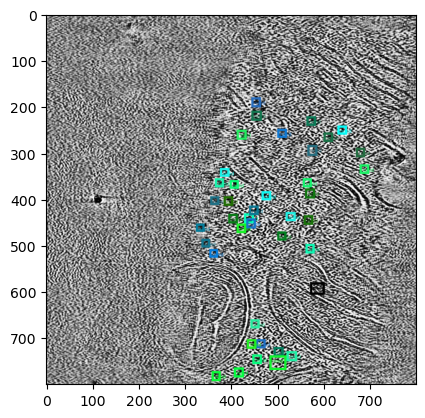

In [16]:
# take one slice and visualize
take = 35
need = []
# subdf = df
# subdf = subdf[subdf["mitochondria"] > 0.05]
for i in retdict["sample_mapping"]:
    if retdict["sample_mapping"][i] == take and i in subdf.index:
        need.append(i)
        
img = retdict["images"][take]
subdf2 = subdf.loc[need]
# subdf2 = subdf

# subdf2 = df.loc[need2]

""" if use dbscan results """
# subdf2 = subdf2[subdf2["label"] != -1]
# subdf2["label"] = subdf2["label"].astype("str")
# print(subdf2.head())

bboxes = subdf2[["ori_x", "ori_y", "ori_w", "ori_h"]].values
bboxes = utils.convertBoxes(torch.tensor(bboxes))
bboxes = torch.tensor(bboxes)*torch.tensor([img.shape[1], img.shape[2], img.shape[1], img.shape[2]])
# bboxes, img.shape
img[0] = img[1]
img[2] = img[1]
labels = {"bboxes": bboxes, "labels": ["need"] * len(bboxes)} 
utils.drawannotation(img, labels, font_size=100)

In [17]:
def find_closest_index_np(lst, target):
    lst = np.array(lst)  # Convert to NumPy array
    closest_index = np.abs(lst - target).argmin()
    return closest_index

In [42]:
sample = subdf[subdf["label"] == 42]
sample

,z,x,y,w,h,ribo,mitochondria,nucleus,endoplasmic_reticulum_or_Golgi,None,ori_x,ori_y,ori_w,ori_h,max,largest,prob,class_value,bbnms,label
2758,189,0.494043,0.969215,0.019630,0.021130,0.622198,0.000024,0.000812,0.000906,0.376060,0.493926,0.968915,0.026166,0.027046,0.622198,ribo,True,0.622198,True,42
2974,194,0.492247,0.969385,0.024633,0.024094,0.860962,0.000002,0.000028,0.000151,0.138857,0.492191,0.969365,0.027644,0.026679,0.860962,ribo,True,0.860962,True,42
3190,199,0.494278,0.969559,0.023334,0.022848,0.764357,0.000082,0.002277,0.006945,0.226339,0.494152,0.969323,0.028371,0.027605,0.764357,ribo,True,0.764357,True,42
3404,204,0.493919,0.970662,0.025472,0.025442,0.869209,0.000006,0.000249,0.000378,0.130159,0.493931,0.970622,0.028852,0.028071,0.869209,ribo,True,0.869209,True,42
3626,209,0.493453,0.968973,0.027133,0.026815,0.878109,0.000005,0.000110,0.000302,0.121475,0.493453,0.968996,0.029148,0.028323,0.878109,ribo,True,0.878109,True,42


In [ ]:
MIN_LENGTH = 10
sample = subdf[subdf["label"] == 42]
sample = sample.sort_values(by="z")
zmin = sample["z"].min()-2
zmax = sample["z"].max()+2
zmid = (zmin + zmax) // 2
if zmin > zmid - MIN_LENGTH:
    zmin = zmid - MIN_LENGTH
if zmax < zmid + MIN_LENGTH:
    zmax = zmid + MIN_LENGTH
inputs = {} 
for i in range(zmin, zmax + 1):
    inputs[i] = {} 
    t = dataset.__getitem__(pos=i)["pixel_values"].unsqueeze(0)
    inputs[i]["image"] = t
    q = find_closest_index_np(sample["z"].values, i)
    inputs[i]["bboxes"] = torch.tensor(sample.iloc[q][["x", "y", "w", "h"]].astype(float).values).unsqueeze(0)
    q = sample.index[q]
    inputs[i]["embed"] = res["embeddings"][q].detach().cpu().unsqueeze(0)

In [19]:
model.stage = "stage mask"
model.eval()
masks = [] 
for i in range(zmin, zmax + 1):
    with torch.no_grad():
        outputs = model(pixel_values=inputs[i]["image"], stage_2_embeds=inputs[i]["embed"], box=inputs[i]["bboxes"])
        outputs = torch.sigmoid(outputs)
    masks.append(outputs.detach().cpu().squeeze(0).numpy())

In [20]:
len(masks)

25

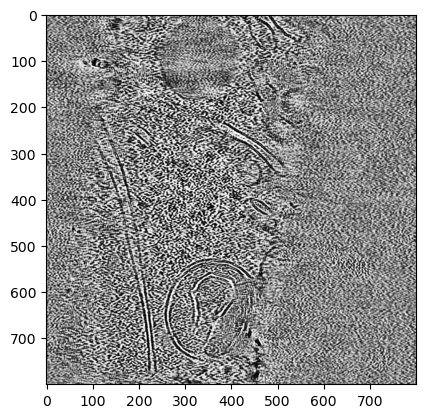

In [282]:
plt.imshow(inputs[200]["image"].squeeze(0).numpy()[1], cmap="gray")

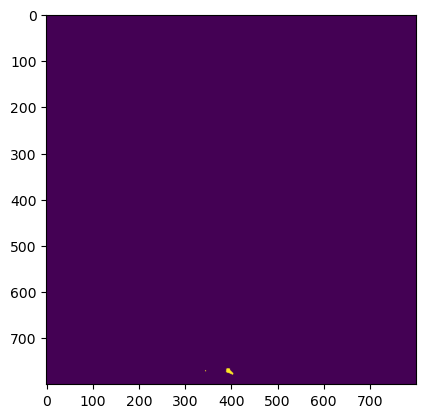

In [47]:
plt.imshow(masks[5]>0.3)

In [38]:
mask = np.stack(masks, axis=0)
mask.shape

(25, 800, 800)

In [51]:
z, x, y = np.where(mask>0.3)

In [52]:
np.mean(x), np.mean(y), np.mean(z)+zmin

(770.888625592417, 392.8059834123223, 200.31783175355451)

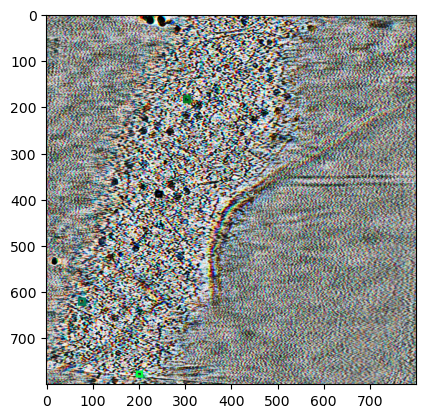

In [20]:
# bboxes = subdf2[["x", "y", "w", "h"]].values

labels = {"bboxes": boxes, "labels": ["test"]*4} 
# img[0] = img[1]
# img[2] = img[1]
utils.drawannotation(img, labels, font_size=100)

In [21]:
pv.shape, embed.shape, boxes.shape

(torch.Size([4, 3, 800, 800]), torch.Size([4, 256]), torch.Size([4, 4]))

In [ ]:
model.stage = "stage mask"
model.eval()
with torch.no_grad():
    outputs = model(pixel_values=pv.float(), stage_2_embeds=embed.float(), box=in_boxes)

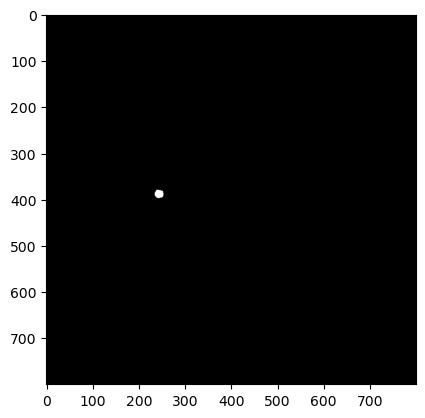

In [23]:
# show one mask
t = outputs[0]
t = torch.sigmoid(t)
plt.imshow(t > 0.3, cmap="gray")

masks


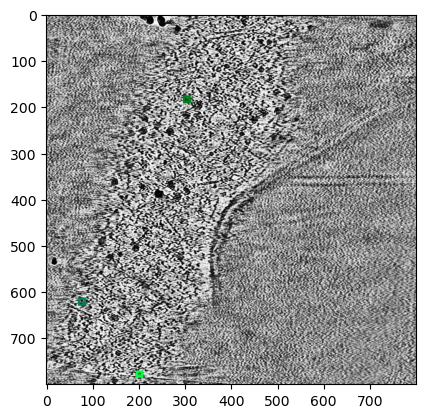

In [24]:
# bboxes = subdf2[["x", "y", "w", "h"]].values
t = outputs.detach().cpu()
labels = {"bboxes": boxes, "labels": ["test"]*4, "masks": t > 0.25, "class_labels":[0, 1, 2, 3]} 
img[0] = img[1]
img[2] = img[1]
utils.drawannotation(img, labels, font_size=100)

In [25]:
# show all four masks
THRES=0.3
q = torch.zeros((800, 800)) 
t = outputs[0].detach()
t = torch.sigmoid(t)
q = q + t > THRES
t = outputs[1].detach()
t = torch.sigmoid(t)
q = q + t > THRES
t = outputs[2].detach()
t = torch.sigmoid(t)
q = q + t > THRES
t = outputs[3].detach()
t = torch.sigmoid(t)
q = q + t > THRES
q = q.unsqueeze(0).repeat(3, 1, 1)  

masks


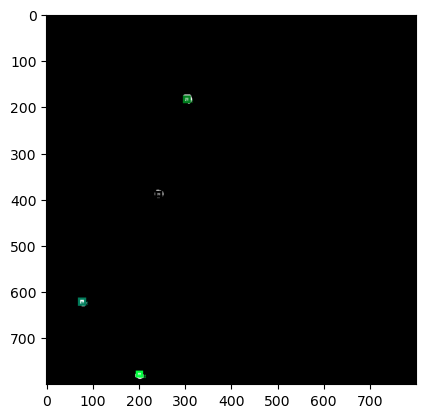

In [26]:
q = q.float()
utils.drawannotation(q, labels, font_size=100)